In [23]:
import pandas as pd
import numpy as np

df = pd.read_csv("friction_formulation.csv")

# 1. 形状：多少行、多少列
print("shape:", df.shape)

# 2. 缺失值总数
print("缺失值总数:", df.isna().sum().sum())

# 3. 闭合校验：19个配方列之和
comp_cols = [c for c in df.columns
             if c not in ["batch_id", "press_temp_C", "press_pressure_MPa",
                          "press_time_min", "post_cure_temp_C", "wear_rate"]]
print("配方列数:", len(comp_cols))
print("闭合和范围: %.2f ~ %.2f" % (df[comp_cols].sum(axis=1).min(),
                                   df[comp_cols].sum(axis=1).max()))

df.head()

shape: (200, 25)
缺失值总数: 0
配方列数: 19
闭合和范围: 100.00 ~ 100.00


,batch_id,phenolic,phenolic_modified,aramid,ceramic_fiber,mineral_fiber,cellulose_fiber,graphite,MoS2,Sb2S3,...,CaCO3,mica,vermiculite,NBR_powder,friction_dust,press_temp_C,press_pressure_MPa,press_time_min,post_cure_temp_C,wear_rate
0,F001,3.578,11.357,5.965,3.627,3.343,7.663,8.557,0.224,0.769,...,10.105,3.448,1.051,6.841,1.914,164.428,21.503,14.570,171.207,0.217
1,F002,14.183,0.853,3.752,3.594,8.488,4.612,11.777,1.730,0.872,...,4.430,8.327,7.154,1.363,5.905,157.616,13.743,14.034,189.459,0.298
2,F003,11.111,3.602,0.367,2.497,7.412,2.738,13.296,0.683,1.807,...,8.208,4.857,1.090,6.546,1.861,167.741,21.392,11.902,193.830,0.453
3,F004,6.143,10.447,0.609,2.168,4.568,4.680,2.651,3.126,3.061,...,8.584,6.500,16.576,10.942,3.323,172.049,18.511,10.963,185.539,0.963
4,F005,6.996,3.381,2.085,0.857,13.161,4.043,8.088,1.345,3.238,...,4.003,5.695,2.845,0.552,12.338,166.158,15.501,14.273,176.353,0.639


count    200.000
mean       0.670
std        0.520
min        0.086
25%        0.363
50%        0.546
75%        0.811
max        4.545

偏度 skewness: 3.135
log后偏度: 0.063


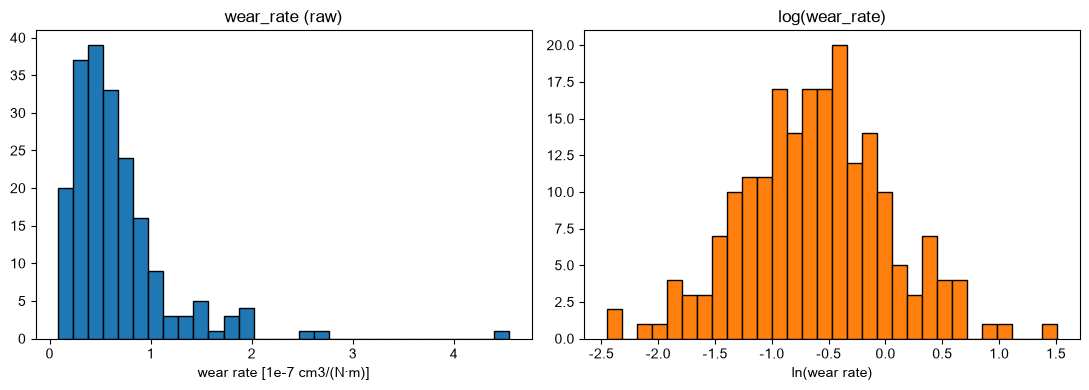

In [24]:
import matplotlib.pyplot as plt

y = df["wear_rate"]

print(y.describe().round(3).to_string())
print("\n偏度 skewness:", round(y.skew(), 3))
print("log后偏度:", round(np.log(y).skew(), 3))

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].hist(y, bins=30, edgecolor="k")
axes[0].set_title("wear_rate (raw)")
axes[0].set_xlabel("wear rate [1e-7 cm3/(N·m)]")

axes[1].hist(np.log(y), bins=30, edgecolor="k", color="tab:orange")
axes[1].set_title("log(wear_rate)")
axes[1].set_xlabel("ln(wear rate)")

plt.tight_layout()
plt.show()

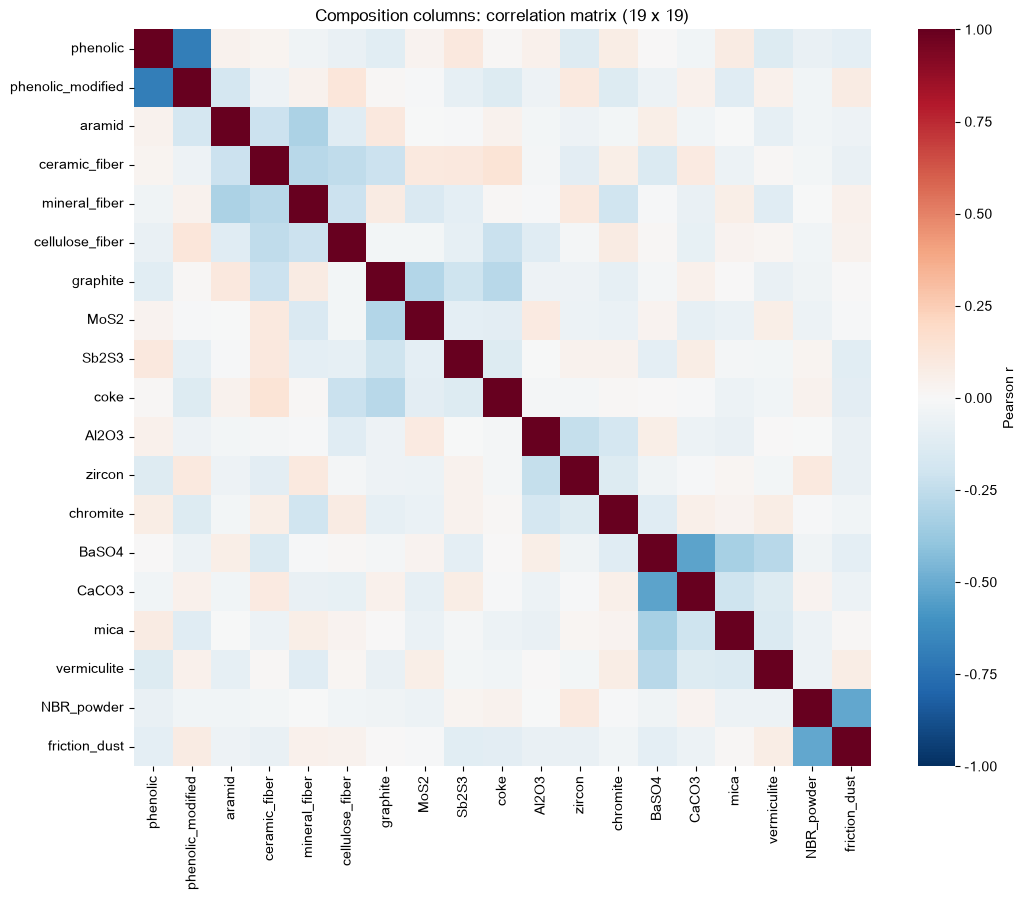

每列 vs 其余列之和 的相关系数：
phenolic            -1.0
vermiculite         -1.0
mica                -1.0
CaCO3               -1.0
BaSO4               -1.0
chromite            -1.0
zircon              -1.0
Al2O3               -1.0
NBR_powder          -1.0
coke                -1.0
MoS2                -1.0
graphite            -1.0
cellulose_fiber     -1.0
mineral_fiber       -1.0
ceramic_fiber       -1.0
aramid              -1.0
phenolic_modified   -1.0
Sb2S3               -1.0
friction_dust       -1.0


In [25]:
df["log_wear"] = np.log(df["wear_rate"])

# 配方列之间的相关系数矩阵
corr = df[comp_cols].corr()

import seaborn as sns
plt.figure(figsize=(11, 9))
sns.heatmap(corr, cmap="RdBu_r", center=0, vmin=-1, vmax=1,
            square=True, annot=False, cbar_kws={"label": "Pearson r"})
plt.title("Composition columns: correlation matrix (19 x 19)")
plt.tight_layout()
plt.show()

# 关键诊断：每一列与"其余18列之和"的相关性
others_sum_corr = {}
for c in comp_cols:
    others = df[comp_cols].drop(columns=c).sum(axis=1)
    others_sum_corr[c] = df[c].corr(others)

print("每列 vs 其余列之和 的相关系数：")
print(pd.Series(others_sum_corr).round(3).sort_values().to_string())

各特征 与 log_wear 的 Pearson 相关系数（升序）：
aramid               -0.698
graphite             -0.350
post_cure_temp_C     -0.222
mica                 -0.108
chromite             -0.089
BaSO4                -0.088
NBR_powder           -0.086
press_pressure_MPa   -0.038
press_temp_C         -0.032
press_time_min       -0.030
Sb2S3                -0.023
phenolic             -0.008
zircon               -0.006
coke                 -0.004
CaCO3                 0.029
cellulose_fiber       0.073
MoS2                  0.095
ceramic_fiber         0.150
vermiculite           0.177
phenolic_modified     0.206
mineral_fiber         0.225
friction_dust         0.229
Al2O3                 0.306


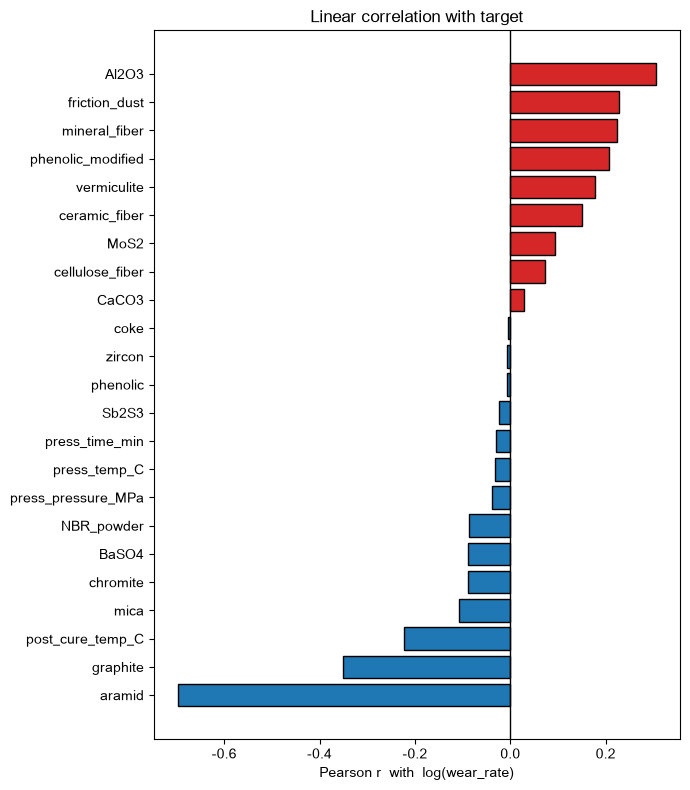

In [26]:
feat_cols = comp_cols + ["press_temp_C", "press_pressure_MPa",
                         "press_time_min", "post_cure_temp_C"]

r_y = df[feat_cols].corrwith(df["log_wear"]).sort_values()
print("各特征 与 log_wear 的 Pearson 相关系数（升序）：")
print(r_y.round(3).to_string())

plt.figure(figsize=(7, 8))
colors = ["tab:blue" if v < 0 else "tab:red" for v in r_y]
plt.barh(r_y.index, r_y.values, color=colors, edgecolor="k")
plt.axvline(0, color="k", lw=1)
plt.xlabel("Pearson r  with  log(wear_rate)")
plt.title("Linear correlation with target")
plt.tight_layout()
plt.show()

binder_total 与 log_wear 的 Pearson r: 0.253
对比 —— phenolic 单独: -0.008


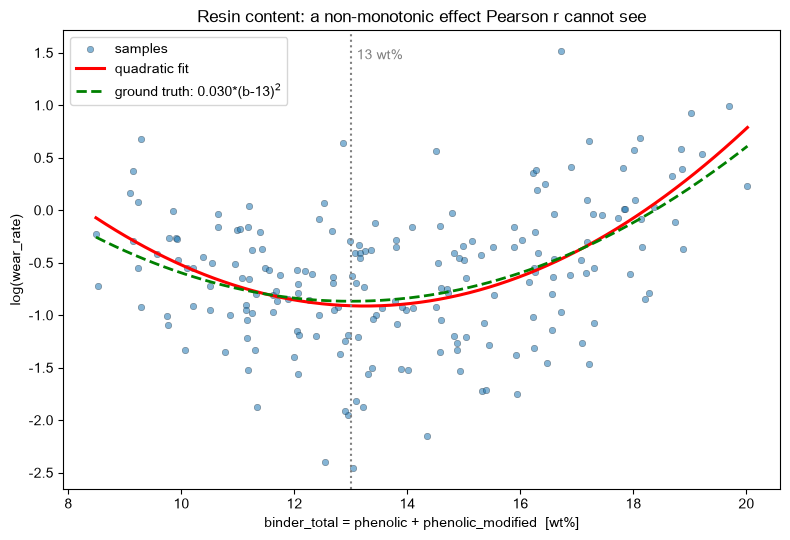


二次拟合的极小值点: 13.25 wt%  (真值 13.00)


In [27]:
# 领域知识：机理作用于"树脂总量"，不是两种酚醛各自
df["binder_total"] = df["phenolic"] + df["phenolic_modified"]

print("binder_total 与 log_wear 的 Pearson r:",
      round(df["binder_total"].corr(df["log_wear"]), 3))
print("对比 —— phenolic 单独:",
      round(df["phenolic"].corr(df["log_wear"]), 3))

x = df["binder_total"]
y = df["log_wear"]

# 二次多项式拟合（承认它是弯的）
coef = np.polyfit(x, y, 2)
xs = np.linspace(x.min(), x.max(), 200)
ys = np.polyval(coef, xs)

# 真值曲线（只有你知道）：0.030*(b-13)^2，加个常数好对齐
truth = 0.030 * (xs - 13.0) ** 2 + (y.mean() - 0.030 * ((x - 13.0) ** 2).mean())

plt.figure(figsize=(8, 5.5))
plt.scatter(x, y, s=22, alpha=0.55, edgecolor="k", linewidth=0.3, label="samples")
plt.plot(xs, ys, "r-", lw=2.2, label="quadratic fit")
plt.plot(xs, truth, "g--", lw=2.0, label="ground truth: 0.030*(b-13)$^2$")
plt.axvline(13.0, color="gray", ls=":", lw=1.5)
plt.text(13.1, y.max()*0.95, "13 wt%", color="gray")
plt.xlabel("binder_total = phenolic + phenolic_modified  [wt%]")
plt.ylabel("log(wear_rate)")
plt.title("Resin content: a non-monotonic effect Pearson r cannot see")
plt.legend()
plt.tight_layout()
plt.show()

# 拟合出的极小值点在哪
print("\n二次拟合的极小值点: %.2f wt%%  (真值 13.00)" % (-coef[1] / (2 * coef[0])))

# 阶段 1：基线模型（线性回归 vs 随机森林）

In [28]:
from sklearn.model_selection import train_test_split

# 目标：log_wear（昨天验证过，加性机理在log空间）
target = "log_wear"

# 工艺特征（4个，与配方独立，无闭合问题）
process_cols = ["press_temp_C", "press_pressure_MPa",
                "press_time_min", "post_cure_temp_C"]

print("配方列 comp_cols:", len(comp_cols), "个")
print("工艺列 process_cols:", len(process_cols), "个")
print("目标:", target)
print("\n可用样本数:", len(df))

配方列 comp_cols: 19 个
工艺列 process_cols: 4 个
目标: log_wear

可用样本数: 200


In [29]:
feat_cols = comp_cols + process_cols   # 选项A：23列全用

X = df[feat_cols]
y = df[target]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("特征数:", X.shape[1])
print("训练集:", X_train.shape[0], "条")
print("测试集:", X_test.shape[0], "条")

特征数: 23
训练集: 160 条
测试集: 40 条


In [30]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_absolute_error

lin = LinearRegression()
lin.fit(X_train, y_train)          # 在训练集上学

pred_train = lin.predict(X_train)  # 回头看训练集
pred_test  = lin.predict(X_test)   # 考试：测试集

print("=== 线性回归 ===")
print("训练集 R²: %.3f" % r2_score(y_train, pred_train))
print("测试集 R²: %.3f" % r2_score(y_test,  pred_test))
print("测试集 MAE: %.3f  (log空间)" % mean_absolute_error(y_test, pred_test))

# 看系数——重点在这
coef = pd.Series(lin.coef_, index=feat_cols).sort_values()
print("\n系数绝对值最大的5个:")
print(coef.reindex(coef.abs().sort_values(ascending=False).index).head(5).round(2).to_string())
print("\n系数绝对值范围: %.2f ~ %.2f" % (coef.abs().min(), coef.abs().max()))

=== 线性回归 ===
训练集 R²: 0.795
测试集 R²: 0.735
测试集 MAE: 0.271  (log空间)

系数绝对值最大的5个:
aramid     -13.87
graphite   -13.79
chromite   -13.74
MoS2       -13.73
Sb2S3      -13.73

系数绝对值范围: 0.00 ~ 13.87


In [31]:
from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor(n_estimators=300, random_state=42, n_jobs=-1)
rf.fit(X_train, y_train)

rf_pred_train = rf.predict(X_train)
rf_pred_test  = rf.predict(X_test)

print("=== 随机森林 ===")
print("训练集 R²: %.3f" % r2_score(y_train, rf_pred_train))
print("测试集 R²: %.3f" % r2_score(y_test,  rf_pred_test))
print("测试集 MAE: %.3f  (log空间)" % mean_absolute_error(y_test, rf_pred_test))

print("\n=== 对比 ===")
print("           线性回归    随机森林")
print("测试集 R²:   %.3f      %.3f" % (
    r2_score(y_test, pred_test), r2_score(y_test, rf_pred_test)))

=== 随机森林 ===
训练集 R²: 0.949
测试集 R²: 0.627
测试集 MAE: 0.287  (log空间)

=== 对比 ===
           线性回归    随机森林
测试集 R²:   0.735      0.627


In [32]:
# ---- 随机森林调参 v1：手动踩刹车 ----
rf_tuned = RandomForestRegressor(
    n_estimators=300,
    max_depth=6,           # 刹车1：树最深6层
    min_samples_leaf=5,    # 刹车2：叶子至少5个样本，不给单点刻坑
    max_features=0.5,      # 刹车3：每次分裂只看一半特征
    random_state=42,
    n_jobs=-1,
).fit(X_train, y_train)

rf_tuned_pred_train = rf_tuned.predict(X_train)
rf_tuned_pred_test  = rf_tuned.predict(X_test)

print("=== 随机森林（调参 v1）===")
print("训练集 R²: %.3f" % r2_score(y_train, rf_tuned_pred_train))
print("测试集 R²: %.3f" % r2_score(y_test,  rf_tuned_pred_test))
print("测试集 MAE: %.3f  (log空间)" % mean_absolute_error(y_test, rf_tuned_pred_test))

print("\n=== 三方对比（测试集 R²）===")
print("线性回归        : %.3f" % r2_score(y_test, pred_test))
print("随机森林(默认)  : %.3f" % r2_score(y_test, rf_pred_test))
print("随机森林(调参v1): %.3f" % r2_score(y_test, rf_tuned_pred_test))

=== 随机森林（调参 v1）===
训练集 R²: 0.834
测试集 R²: 0.555
测试集 MAE: 0.324  (log空间)

=== 三方对比（测试集 R²）===
线性回归        : 0.735
随机森林(默认)  : 0.627
随机森林(调参v1): 0.555


In [33]:
from sklearn.model_selection import GridSearchCV

# 让机器帮我们试各种"刹车力度"的组合
param_grid = {
    "max_depth":        [4, 6, 8, 12, None],
    "min_samples_leaf": [1, 2, 5, 10],
    "max_features":     [0.3, 0.5, 0.7, 1.0],
}

rf_base = RandomForestRegressor(n_estimators=300, random_state=42, n_jobs=-1)

grid = GridSearchCV(
    rf_base, param_grid,
    cv=5,              # 5折交叉验证：切5份轮流验证，取平均，比单一40点稳
    scoring="r2",
    n_jobs=-1,
)
grid.fit(X_train, y_train)

print("机器选出的最优刹车:", grid.best_params_)
print("交叉验证最优 R²: %.3f" % grid.best_score_)

best_rf = grid.best_estimator_
print("\n=== 最优随机森林（测试集验收）===")
print("训练集 R²: %.3f" % r2_score(y_train, best_rf.predict(X_train)))
print("测试集 R²: %.3f" % r2_score(y_test,  best_rf.predict(X_test)))

机器选出的最优刹车: {'max_depth': 8, 'max_features': 0.5, 'min_samples_leaf': 1}
交叉验证最优 R²: 0.611

=== 最优随机森林（测试集验收）===
训练集 R²: 0.945
测试集 R²: 0.595


In [34]:
from sklearn.ensemble import GradientBoostingRegressor

# GBDT 的参数配合：学得慢(learning_rate小) 就要种更多树(n_estimators大)
gb_grid = {
    "n_estimators":  [200, 400, 800],
    "learning_rate": [0.02, 0.05, 0.1],
    "max_depth":     [2, 3],           # 浅树 = 弱学习器，GBDT 的精髓
    "subsample":     [0.7, 1.0],       # 每棵树只用部分样本，抗噪
}

gb_base = GradientBoostingRegressor(random_state=42)

gb_search = GridSearchCV(
    gb_base, gb_grid,
    cv=5, scoring="r2", n_jobs=-1,
)
gb_search.fit(X_train, y_train)

print("GBDT 最优参数:", gb_search.best_params_)
print("交叉验证最优 R²: %.3f" % gb_search.best_score_)

best_gb = gb_search.best_estimator_
print("\n=== 最优 GBDT（测试集验收）===")
print("训练集 R²: %.3f" % r2_score(y_train, best_gb.predict(X_train)))
print("测试集 R²: %.3f" % r2_score(y_test,  best_gb.predict(X_test)))

print("\n=== 四方对比（测试集 R²）===")
print("线性回归        : %.3f" % r2_score(y_test, pred_test))
print("随机森林(默认)  : %.3f" % r2_score(y_test, rf_pred_test))
print("随机森林(最优)  : %.3f" % r2_score(y_test, best_rf.predict(X_test)))
print("GBDT(最优)      : %.3f" % r2_score(y_test, best_gb.predict(X_test)))

GBDT 最优参数: {'learning_rate': 0.02, 'max_depth': 2, 'n_estimators': 800, 'subsample': 0.7}
交叉验证最优 R²: 0.711

=== 最优 GBDT（测试集验收）===
训练集 R²: 0.988
测试集 R²: 0.705

=== 四方对比（测试集 R²）===
线性回归        : 0.735
随机森林(默认)  : 0.627
随机森林(最优)  : 0.595
GBDT(最优)      : 0.705


In [35]:
import pandas as pd

# 从 best_gb 拉出每个特征的重要性
importance = pd.Series(
    best_gb.feature_importances_,
    index=X_train.columns
).sort_values(ascending=False)

# 标记：哪些是你埋的真机理，哪些是噪声对照组
true_mechanism = ["aramid", "graphite", "Al2O3", "friction_dust",
                  "post_cure_temp_C", "phenolic", "phenolic_modified"]

print("=== GBDT 特征重要性排名（高→低）===\n")
for rank, (feat, imp) in enumerate(importance.items(), 1):
    tag = "  ← 真机理" if feat in true_mechanism else ""
    print(f"{rank:2d}. {feat:22s} {imp:.4f}{tag}")

=== GBDT 特征重要性排名（高→低）===

 1. aramid                 0.4905  ← 真机理
 2. Al2O3                  0.1183  ← 真机理
 3. graphite               0.0918  ← 真机理
 4. friction_dust          0.0739  ← 真机理
 5. post_cure_temp_C       0.0524  ← 真机理
 6. phenolic_modified      0.0424  ← 真机理
 7. chromite               0.0225
 8. mica                   0.0156
 9. cellulose_fiber        0.0134
10. phenolic               0.0119  ← 真机理
11. vermiculite            0.0096
12. press_time_min         0.0078
13. press_temp_C           0.0072
14. zircon                 0.0069
15. CaCO3                  0.0065
16. mineral_fiber          0.0061
17. NBR_powder             0.0056
18. coke                   0.0037
19. BaSO4                  0.0031
20. MoS2                   0.0030
21. press_pressure_MPa     0.0030
22. Sb2S3                  0.0025
23. ceramic_fiber          0.0023


In [36]:
# ---- 领域知识注入：树脂总量合体 ----
# 用 binder_total 替换 phenolic + phenolic_modified 两列（不能三列同喂，会共线）
X_train_v2 = X_train.copy()
X_test_v2  = X_test.copy()

X_train_v2["binder_total"] = X_train_v2["phenolic"] + X_train_v2["phenolic_modified"]
X_test_v2["binder_total"]  = X_test_v2["phenolic"]  + X_test_v2["phenolic_modified"]

X_train_v2 = X_train_v2.drop(columns=["phenolic", "phenolic_modified"])
X_test_v2  = X_test_v2.drop(columns=["phenolic", "phenolic_modified"])

print("特征数：%d → %d（两列合体成一列）" % (X_train.shape[1], X_train_v2.shape[1]))

# ---- 用同样的最优参数，在新特征上重训 ----
best_gb_v2 = GradientBoostingRegressor(
    **gb_search.best_params_, random_state=42
).fit(X_train_v2, y_train)

print("\n=== binder_total 版 GBDT ===")
print("测试集 R²: %.3f  (合体前: 0.705)" % r2_score(y_test, best_gb_v2.predict(X_test_v2)))

# ---- 重新拉重要性 ----
importance_v2 = pd.Series(
    best_gb_v2.feature_importances_,
    index=X_train_v2.columns
).sort_values(ascending=False)

true_mechanism_v2 = ["aramid", "graphite", "Al2O3", "friction_dust",
                     "post_cure_temp_C", "binder_total"]

print("\n=== 特征重要性排名（binder_total 版）===\n")
for rank, (feat, imp) in enumerate(importance_v2.items(), 1):
    tag = "  ← 真机理" if feat in true_mechanism_v2 else ""
    print(f"{rank:2d}. {feat:22s} {imp:.4f}{tag}")

特征数：23 → 22（两列合体成一列）

=== binder_total 版 GBDT ===
测试集 R²: 0.892  (合体前: 0.705)

=== 特征重要性排名（binder_total 版）===

 1. aramid                 0.4964  ← 真机理
 2. binder_total           0.1563  ← 真机理
 3. Al2O3                  0.1101  ← 真机理
 4. graphite               0.0798  ← 真机理
 5. friction_dust          0.0676  ← 真机理
 6. post_cure_temp_C       0.0382  ← 真机理
 7. chromite               0.0153
 8. zircon                 0.0089
 9. cellulose_fiber        0.0048
10. mica                   0.0031
11. vermiculite            0.0029
12. mineral_fiber          0.0029
13. press_temp_C           0.0025
14. press_time_min         0.0021
15. Sb2S3                  0.0021
16. MoS2                   0.0014
17. NBR_powder             0.0012
18. BaSO4                  0.0012
19. ceramic_fiber          0.0011
20. CaCO3                  0.0011
21. coke                   0.0008
22. press_pressure_MPa     0.0003


In [37]:
from sklearn.inspection import permutation_importance

# 在测试集上做置换重要性：打乱每列 30 次，看分数掉多少
perm = permutation_importance(
    best_gb_v2, X_test_v2, y_test,
    n_repeats=30,          # 每列打乱30次，取平均+标准差
    random_state=42,
    scoring="r2",
    n_jobs=-1,
)

perm_imp = pd.Series(perm.importances_mean, index=X_test_v2.columns)
perm_std = pd.Series(perm.importances_std,  index=X_test_v2.columns)
perm_imp = perm_imp.sort_values(ascending=False)

true_mechanism_v2 = ["aramid", "graphite", "Al2O3", "friction_dust",
                     "post_cure_temp_C", "binder_total"]

print("=== 置换重要性排名（测试集，打乱后 R² 掉了多少）===\n")
for rank, (feat, imp) in enumerate(perm_imp.items(), 1):
    std = perm_std[feat]
    tag = "  ← 真机理" if feat in true_mechanism_v2 else ""
    print(f"{rank:2d}. {feat:22s} {imp:.4f} ± {std:.4f}{tag}")

=== 置换重要性排名（测试集，打乱后 R² 掉了多少）===

 1. aramid                 0.7476 ± 0.1183  ← 真机理
 2. binder_total           0.3512 ± 0.0728  ← 真机理
 3. graphite               0.0892 ± 0.0266  ← 真机理
 4. Al2O3                  0.0884 ± 0.0218  ← 真机理
 5. friction_dust          0.0824 ± 0.0227  ← 真机理
 6. post_cure_temp_C       0.0485 ± 0.0149  ← 真机理
 7. mineral_fiber          0.0055 ± 0.0018
 8. chromite               0.0050 ± 0.0042
 9. press_time_min         0.0014 ± 0.0009
10. cellulose_fiber        0.0010 ± 0.0011
11. ceramic_fiber          0.0009 ± 0.0011
12. MoS2                   0.0006 ± 0.0007
13. Sb2S3                  0.0005 ± 0.0009
14. BaSO4                  0.0004 ± 0.0007
15. press_pressure_MPa     0.0003 ± 0.0004
16. CaCO3                  0.0003 ± 0.0006
17. mica                   0.0002 ± 0.0010
18. press_temp_C           -0.0000 ± 0.0005
19. coke                   -0.0003 ± 0.0006
20. vermiculite            -0.0005 ± 0.0009
21. NBR_powder             -0.0008 ± 0.0009
22. zircon        

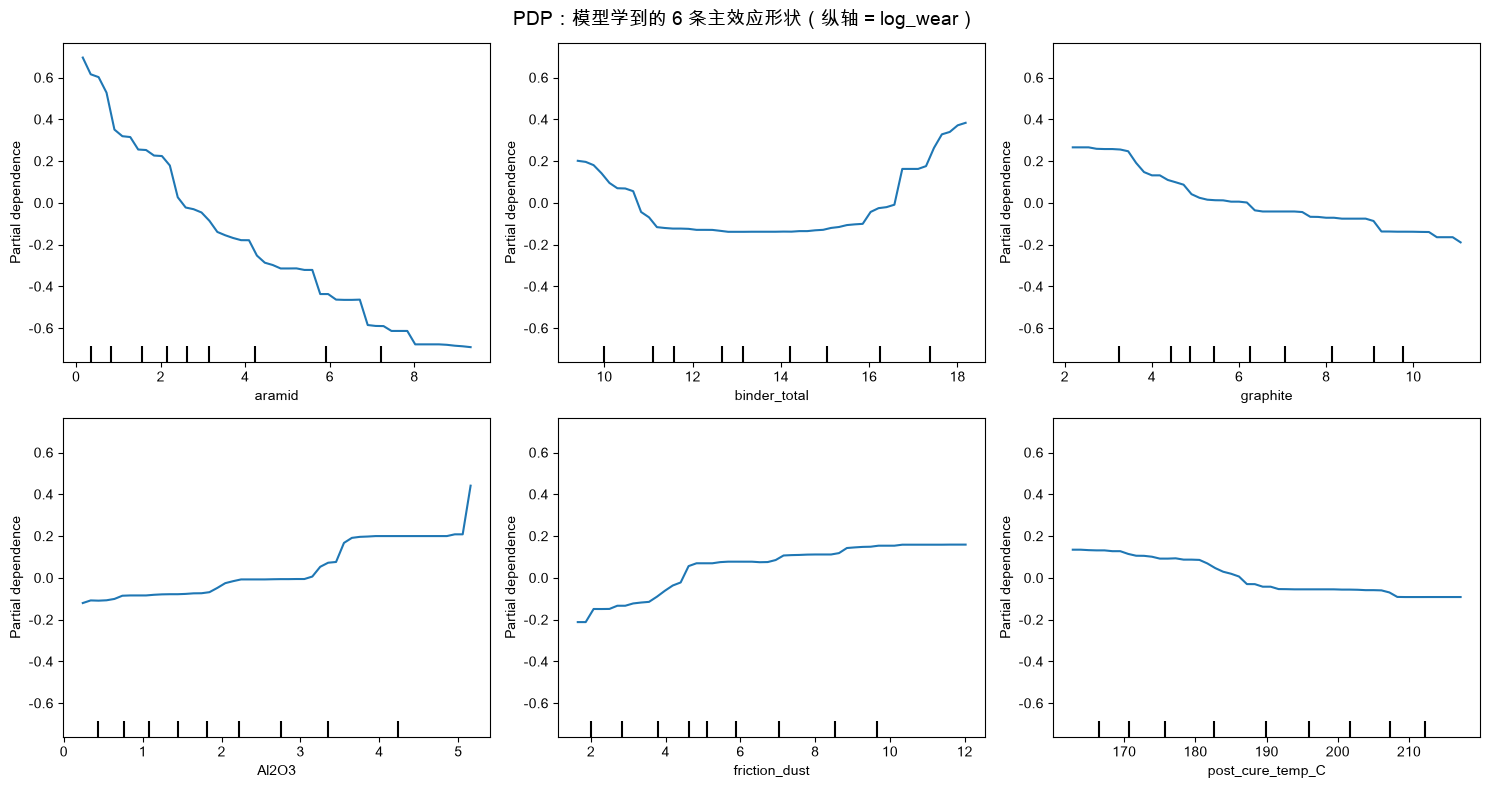

In [38]:
import matplotlib.pyplot as plt
from sklearn.inspection import PartialDependenceDisplay

# macOS 中文字体，避免标题变成方块
plt.rcParams["font.sans-serif"] = ["Arial Unicode MS"]
plt.rcParams["axes.unicode_minus"] = False

six = ["aramid", "binder_total", "graphite", "Al2O3", "friction_dust", "post_cure_temp_C"]

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
PartialDependenceDisplay.from_estimator(
    best_gb_v2, X_train_v2, features=six,
    ax=axes.ravel(), grid_resolution=50
)
fig.suptitle("PDP：模型学到的 6 条主效应形状（纵轴 = log_wear）", fontsize=14)
fig.tight_layout()
plt.show()

In [39]:
import numpy as np
a = X_train_v2["Al2O3"]
print("十分位刻度（图上10根竖线的位置）：")
print(np.round(np.percentile(a, np.arange(10, 100, 10)), 2))
print(f"\n数据实际最大值：{a.max():.2f}")
print(f"最后一根竖线(90%分位={np.percentile(a,90):.2f})右边还有 {(a > np.percentile(a,90)).sum()} 个样本")

十分位刻度（图上10根竖线的位置）：
[0.45 0.77 1.09 1.45 1.82 2.21 2.75 3.33 4.22]

数据实际最大值：7.26
最后一根竖线(90%分位=4.22)右边还有 16 个样本


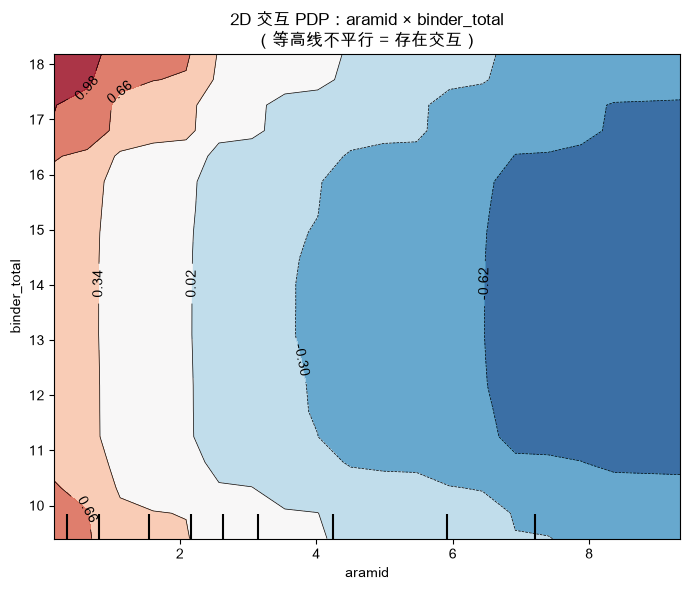

In [40]:
fig, ax = plt.subplots(figsize=(7, 6))
PartialDependenceDisplay.from_estimator(
    best_gb_v2, X_train_v2,
    features=[("aramid", "binder_total")],   # 元组 = 二维交互
    ax=ax, grid_resolution=20,
    contour_kw={"cmap": "RdBu_r", "alpha": 0.85}
)
ax.set_title("2D 交互 PDP：aramid × binder_total\n（等高线不平行 = 存在交互）", fontsize=12)
fig.tight_layout()
plt.show()

形状自检 —— Z2: (20, 20)  fA: (20,)  fB: (20,)


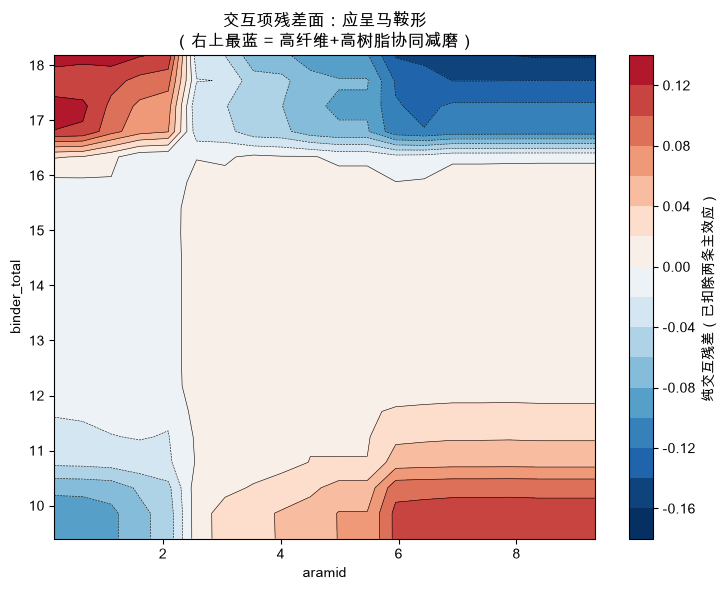

交互残差幅度：-0.162 ~ 0.131
（作参照）主效应幅度：aramid 1.386，binder 0.522


In [41]:
from sklearn.inspection import partial_dependence

# 注意：partial_dependence 用平列表表示二维交互（不是元组）
r2 = partial_dependence(best_gb_v2, X_train_v2,
                        features=["aramid", "binder_total"],
                        grid_resolution=20, kind="average")
rA = partial_dependence(best_gb_v2, X_train_v2, features=["aramid"],
                        grid_resolution=20, kind="average")
rB = partial_dependence(best_gb_v2, X_train_v2, features=["binder_total"],
                        grid_resolution=20, kind="average")

gv = r2["grid_values"] if "grid_values" in r2 else r2["values"]
ga, gb = gv[0], gv[1]

Z2 = r2["average"][0]          # 二维曲面 (aramid, binder)
fA = rA["average"][0]          # aramid 主效应
fB = rB["average"][0]          # binder 主效应
print("形状自检 —— Z2:", Z2.shape, " fA:", fA.shape, " fB:", fB.shape)

inter = Z2 - fA[:, None] - fB[None, :]   # 扣掉加性部分
inter = inter - inter.mean()             # 去掉常数偏移，只看形状

fig, ax = plt.subplots(figsize=(7.5, 6))
lim = np.abs(inter).max()
cf = ax.contourf(ga, gb, inter.T, levels=14, cmap="RdBu_r",
                 vmin=-lim, vmax=lim)
ax.contour(ga, gb, inter.T, levels=14, colors="k", linewidths=0.4)
fig.colorbar(cf, ax=ax, label="纯交互残差（已扣除两条主效应）")
ax.set_xlabel("aramid"); ax.set_ylabel("binder_total")
ax.set_title("交互项残差面：应呈马鞍形\n（右上最蓝 = 高纤维+高树脂协同减磨）", fontsize=12)
fig.tight_layout()
plt.show()

print(f"交互残差幅度：{inter.min():.3f} ~ {inter.max():.3f}")
print(f"（作参照）主效应幅度：aramid {np.ptp(fA):.3f}，binder {np.ptp(fB):.3f}")

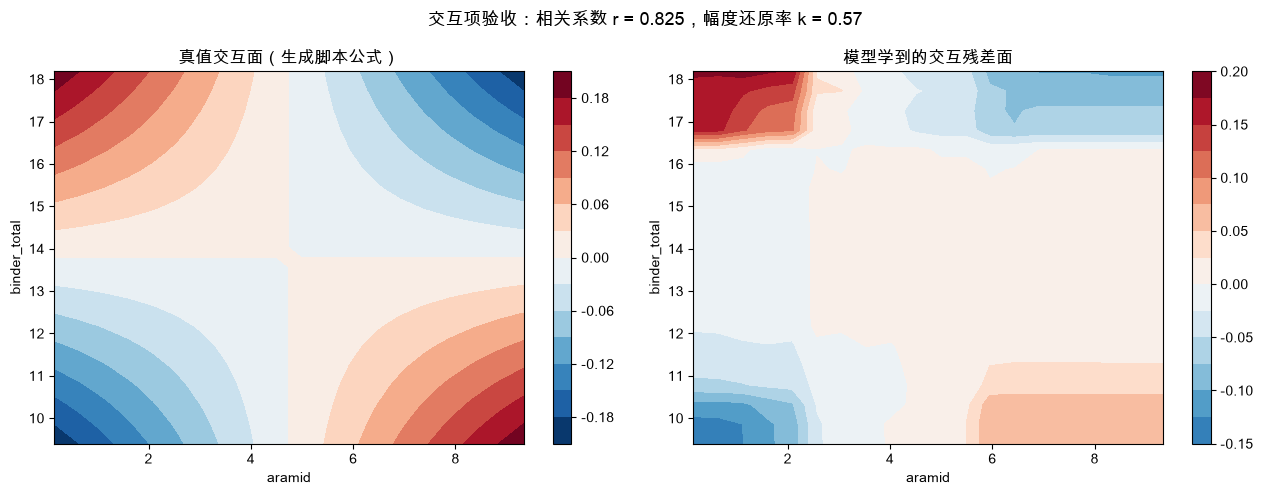

相关系数 r      = 0.8253   （形状是否一致）
回归斜率 k      = 0.575    （幅度学到了几成，1.0 = 学满）
真值面幅度      = -0.201 ~ 0.201
模型面幅度      = -0.135 ~ 0.185


In [42]:
# ---- 真值交互面（同一网格）----
A_grid, B_grid = np.meshgrid(ga, gb, indexing="ij")   # (20,20)
T_true = -0.010 * A_grid * (B_grid - 10.0)

# ---- 双重中心化：剥掉所有加性成分，只留纯交互 ----
def double_center(M):
    return M - M.mean(axis=1, keepdims=True) - M.mean(axis=0, keepdims=True) + M.mean()

T_true_c  = double_center(T_true)
T_model_c = double_center(inter)

# ---- 量化 ----
r = np.corrcoef(T_model_c.ravel(), T_true_c.ravel())[0, 1]
k = np.linalg.lstsq(T_true_c.ravel()[:, None], T_model_c.ravel(), rcond=None)[0][0]

# ---- 并排看 ----
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
lim = max(np.abs(T_true_c).max(), np.abs(T_model_c).max())
for ax, M, ttl in zip(axes, [T_true_c, T_model_c],
                      ["真值交互面（生成脚本公式）", "模型学到的交互残差面"]):
    cf = ax.contourf(ga, gb, M.T, levels=14, cmap="RdBu_r", vmin=-lim, vmax=lim)
    ax.set_xlabel("aramid"); ax.set_ylabel("binder_total"); ax.set_title(ttl)
    fig.colorbar(cf, ax=ax)
fig.suptitle(f"交互项验收：相关系数 r = {r:.3f}，幅度还原率 k = {k:.2f}", fontsize=13)
fig.tight_layout()
plt.show()

print(f"相关系数 r      = {r:.4f}   （形状是否一致）")
print(f"回归斜率 k      = {k:.3f}    （幅度学到了几成，1.0 = 学满）")
print(f"真值面幅度      = {T_true_c.min():.3f} ~ {T_true_c.max():.3f}")
print(f"模型面幅度      = {T_model_c.min():.3f} ~ {T_model_c.max():.3f}")